In [45]:
import torch
from torch import nn, optim
import torchvision
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from math import isqrt

In [46]:
# IMage
D_image = 96
N_CHANNELS = 3

PATCH_SIZE = 8
D_patch = (PATCH_SIZE**2) * N_CHANNELS # 192
N_PATCHES = (D_image**2) // (PATCH_SIZE**2) # 144
N_ROWS = isqrt(N_PATCHES)

# Encoder
D = 192
N_HEADS = 3
Dk = D // N_HEADS # 64
D_mlp = 4*D

# Decoder
D_decoder = D # normally D//2 but ViT-Tiny with 1 Transformer block is already so shallow
# D == D_decoder means I can use the same positional embeddings
D_decoder_mlp = 4*D_decoder

In [47]:
# Transforms
transform = transforms.Compose([
    transforms.RandomResizedCrop(D_image, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
])

In [ ]:
# Download and load datasets
supervised_trainset = torchvision.datasets.STL10(
    root='./data', split='train', download=True, transform=transform
)
testset = torchvision.datasets.STL10(
    root='./data', split='test', download=True, transform=transform
)
unlabeled_set = torchvision.datasets.STL10(
    root='./data', split='unlabeled', download=True, transform=transform
)

In [ ]:
# DataLoaders
BATCH_SIZE = 256
supervised_trainloader = torch.utils.data.DataLoader(
    supervised_trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)
ssl_trainloader = torch.utils.data.DataLoader(
    unlabeled_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

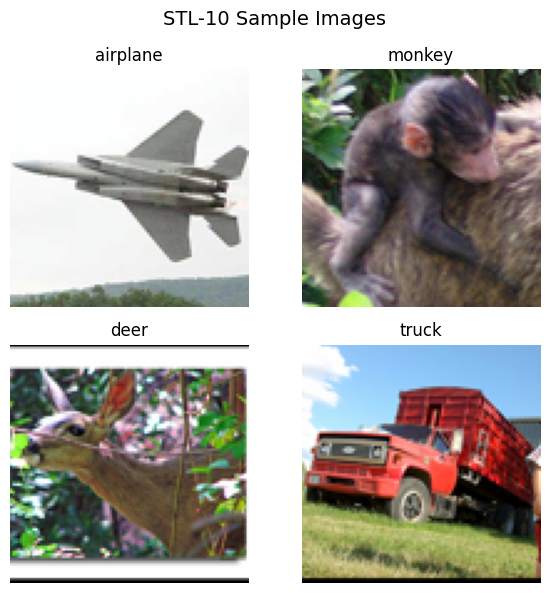

Supervised train samples : 5000
Unlabeled (SSL) samples  : 100000
Test samples             : 8000


In [ ]:
# Class labels (unlabeled split has no classes)
classes = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

# Display 4 images in a 2x2 grid
def imshow(img):
    mean = np.array([0.4467, 0.4398, 0.4066])
    std  = np.array([0.2603, 0.2566, 0.2713])
    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean  # unnormalize
    return np.clip(img, 0, 1)

images, labels = next(iter(supervised_trainloader))
images = images[:4]
labels = labels[:4]

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(imshow(images[i]))
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.suptitle('STL-10 Sample Images', fontsize=14)
plt.tight_layout()
plt.savefig('stl10_grid.png', dpi=150)
plt.show()

print(f"Supervised train samples : {len(supervised_trainset)}")
print(f"Unlabeled (SSL) samples  : {len(unlabeled_set)}")
print(f"Test samples             : {len(testset)}")

In [ ]:
device = torch.device('cuda:0')

# Calculate 2D sine-cosine position embeddings

Each axis gets 1/2 of the embedding dimension, so D = 192 so $D_{pos}=96$

Ok so for each axis I should end up with a matrix of N_PATCHES x $D_{pos}$ 

Because $D == D_{decoder}$ I can just create the positional embeddings once and don't need separate for the encoder and the decoder

In [ ]:
# My long-implementation
# Calculate our 2D sine-cosine position embeddings
D_pos = D // 2 # 96
# I need to make sure the way I view and unview the patches is the same
N_ROWS = isqrt(N_PATCHES)
row_pos = np.zeros((N_ROWS, D_pos))
col_pos = np.zeros((N_ROWS, D_pos))

i = np.arange(D_pos // 2) # half sine, half cosine
denominators = 10000 ** (2 * i / D_pos)

for row in range(0, N_ROWS):
    row_pos[row, 0::2] = np.sin(row / denominators) # even inddicies
    row_pos[row, 1::2] = np.cos(row / denominators) # odd indicies

for col in range(0, N_ROWS):
    col_pos[col, 0::2] = np.sin(col / denominators) # even inddicies
    col_pos[col, 1::2] = np.cos(col / denominators) # odd indicies

pos_embeddings = np.zeros((N_PATCHES, D))
for row in range(0, N_ROWS):
    for col in range(0, N_ROWS):
        pos_embeddings[row*N_ROWS + col, :] = np.concatenate([row_pos[row, :], col_pos[col, :]])
pos_embeddings = torch.tensor(pos_embeddings, dtype=torch.float32)
pos_embeddings = pos_embeddings.to(device)
pos_embeddings
assert pos_embeddings.device == torch.device('cuda:0'), f"pos_embeddings is on {pos_embeddings.device}"

In [ ]:
# # Concise implementation
# D_pos = D // 2
# i = np.arange(D_pos // 2)
# denominators = 10000 ** (2 * i / D_pos)

# # [N_ROWS, D_pos]
# pe = np.zeros((N_ROWS, D_pos))
# # use numpy's dimension insertion syntax with None
# pe[:, 0::2] = np.sin(np.arange(N_ROWS)[:, None] / denominators[None, :]) # fill out even indices
# pe[:, 1::2] = np.cos(np.arange(N_ROWS)[:, None] / denominators[None, :]) # fill out odd indices

# # index into pe for each patch's row and col
# rows = np.repeat(np.arange(N_ROWS), N_ROWS) # [0,0,0,1,1,1...]
# cols = np.tile(np.arange(N_ROWS), N_ROWS) # repeats the whole array N_row times

# # [N_PATCHES, D]
# pos_embeddings = np.concatenate([pe[rows], pe[cols]], axis=1)

In [ ]:
torch.autograd.set_detect_anomaly(False, check_nan=False)

In [ ]:
class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()

        ### ENCODER

        self.img2enc_projection = nn.Linear(D_patch, D)

        # Block 1
        self.norm1a = nn.LayerNorm(D)
        self.msa1 = nn.MultiheadAttention(D, N_HEADS, batch_first=True)
        self.norm1b = nn.LayerNorm(D)
        self.mlp1a = nn.Linear(D, D_mlp)
        self.mlp1b = nn.Linear(D_mlp, D)

        # Block 2
        self.norm2a = nn.LayerNorm(D)
        self.msa2 = nn.MultiheadAttention(D, N_HEADS, batch_first=True)
        self.norm2b = nn.LayerNorm(D)
        self.mlp2a = nn.Linear(D, D_mlp)
        self.mlp2b = nn.Linear(D_mlp, D)

        # Block 3
        self.norm3a = nn.LayerNorm(D)
        self.msa3 = nn.MultiheadAttention(D, N_HEADS, batch_first=True)
        self.norm3b = nn.LayerNorm(D)
        self.mlp3a = nn.Linear(D, D_mlp)
        self.mlp3b = nn.Linear(D_mlp, D)

        ### DECODER (just single transformer block)
        self.masked_embedding = nn.Parameter(torch.randn(1, 1, D_decoder))
        self.enc2dec_projection = nn.Linear(D, D_decoder)
        self.decoder_norm1 = nn.LayerNorm(D_decoder)
        self.decoder_msa = nn.MultiheadAttention(D_decoder, N_HEADS, batch_first=True)
        self.decoder_norm2 = nn.LayerNorm(D_decoder)
        self.decoder_mlp1 = nn.Linear(D_decoder, D_decoder_mlp)
        self.decoder_mlp2 = nn.Linear(D_decoder_mlp, D_decoder)
        self.dec2img_projection = nn.Linear(D_decoder, D_patch)

    def forward(self, x):
        # x is (B, C, H, W) = (B, 3, 96, 96)
        B, C, H, W = x.shape

        # Make (B, 3, 12, 12, 8, 8)
        patches = x.unfold(2, PATCH_SIZE, PATCH_SIZE).unfold(3, PATCH_SIZE, PATCH_SIZE)
        assert patches.shape == (B, N_CHANNELS, N_ROWS, N_ROWS, PATCH_SIZE, PATCH_SIZE), patches.shape 
        
        # Make (B, 12, 12, 3, 8, 8)
        x = patches.permute(0, 2, 3, 1, 4, 5).contiguous()
        assert x.shape == (B, N_ROWS, N_ROWS, N_CHANNELS, PATCH_SIZE, PATCH_SIZE), x.shape

        x = x.view(B, N_ROWS, N_ROWS, -1)
        assert x.shape == (B, N_ROWS, N_ROWS, D_patch)

        SEQ = N_PATCHES # N_ROWS ** 2

        x = x.view(B, SEQ, D_patch)
        assert x.shape == (B, 144, 192), x.shape
        truth_patches = x

        # Ok we have our embeddigs of the image
        # now we need to add our constant sine-cosine position embeddings
        x = x + pos_embeddings

        # Create a mask and apply it
        noise = torch.rand(B, SEQ, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1) # Get a list of sorted ids for each B
        n_keep = int(SEQ * 0.25)
        n_not_keep = SEQ - n_keep
        ids_unmasked = ids_shuffle[:, :n_keep] # Store the ids of first 25% -> (B, n_keep)
        ids_masked = ids_shuffle[:, n_keep:] # Store the ids of last 75% -> (B, n_masked)

        # x_unmasked we want (B, n_keep, 192)
        ind_unmasked_enc = ids_unmasked.unsqueeze(-1).expand(-1, -1, D_patch) # (B, n_keep, D)
        ind_unmasked_dec = ids_unmasked.unsqueeze(-1).expand(-1, -1, D_decoder) # (B, n_keep, D)

        # For dim=1, keep all dimensions the same but replaces with the column index
        x_unmasked = torch.gather(x, 1, ind_unmasked_enc)
        assert x_unmasked.shape == (B, n_keep, 192), x_unmasked.shape

        # Pass the 25% through the encoder
        # define the encoder
        embeddings = self.img2enc_projection(x_unmasked)
        # Block 1
        x = self.norm1a(embeddings)
        x, _ = self.msa1(x, x, x)
        embeddings = embeddings + x # skip connection
        x = self.norm1b(embeddings)
        x = F.gelu( self.mlp1a(x) )
        x = self.mlp1b(x)
        embeddings = embeddings + x # skip connection
        # Block 2
        x = self.norm2a(embeddings)
        x, _ = self.msa2(x, x, x)
        embeddings = embeddings + x # skip connection
        x = self.norm2b(embeddings)
        x = F.gelu( self.mlp2a(x) )
        x = self.mlp2b(x)
        embeddings = embeddings + x # skip connection
        # Block 3
        x = self.norm3a(embeddings)
        x, _ = self.msa3(x, x, x)
        embeddings = embeddings + x # skip connection
        x = self.norm3b(embeddings)
        x = F.gelu( self.mlp3a(x) )
        x = self.mlp3b(x)
        embeddings = embeddings + x # skip connection

        ## DECODER
        x = self.masked_embedding.repeat(B, N_PATCHES, 1)
        assert x.shape == (B, N_PATCHES, D_decoder), x.shape
        unmasked_embeddings_dec = self.enc2dec_projection(embeddings)
        embeddings_dec = x.clone().scatter(1, ind_unmasked_dec, unmasked_embeddings_dec)
        # embeddings_dec = torch.scatter(x, 1, ind_unmasked_dec, unmasked_embeddings_dec)
        embeddings_dec = embeddings_dec + pos_embeddings
        x = self.decoder_norm1(embeddings_dec)
        x, _ = self.decoder_msa(x, x, x)
        embeddings_dec = embeddings_dec + x
        x = self.decoder_norm2(embeddings_dec)
        x = F.gelu( self.decoder_mlp1(x) )
        x = self.decoder_mlp2(x)
        embeddings_dec = embeddings_dec + x
        y_patches = self.dec2img_projection(embeddings_dec)

        return y_patches, truth_patches, ids_masked

net = Net()
net.to(device)

Net(
  (img2enc_projection): Linear(in_features=192, out_features=192, bias=True)
  (norm1a): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (msa1): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
  )
  (norm1b): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (mlp1a): Linear(in_features=192, out_features=768, bias=True)
  (mlp1b): Linear(in_features=768, out_features=192, bias=True)
  (norm2a): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (msa2): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
  )
  (norm2b): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (mlp2a): Linear(in_features=192, out_features=768, bias=True)
  (mlp2b): Linear(in_features=768, out_features=192, bias=True)
  (norm3a): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (msa3): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinea

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(net.parameters(), 1.5e-4, (0.9, 0.95), 1e-8, 0.05)
for epoch in range(200):
    running_loss = 0.0
    for i, data in enumerate(ssl_trainloader):
        inputs = data[0].to(device)

        optimizer.zero_grad()

        y_pred_patches, y_true_patches, ids_masked = net(inputs)
        masked_indices = ids_masked.unsqueeze(-1).expand(-1, -1, D_patch)
        y_pred_masked_patches = torch.gather(y_pred_patches, 1, masked_indices)
        
        with torch.no_grad():
            y_true_patches = torch.gather(y_true_patches, 1, masked_indices)
            
        loss = criterion(y_pred_masked_patches, y_true_patches)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.6f}')
            running_loss = 0.0
print('Finished training')

[1,   100] loss: 0.906196
[1,   200] loss: 0.663835
[1,   300] loss: 0.573644
[2,   100] loss: 0.486638
[2,   200] loss: 0.459108
[2,   300] loss: 0.445267
[3,   100] loss: 0.416676
[3,   200] loss: 0.406411
[3,   300] loss: 0.400093
[4,   100] loss: 0.389465
[4,   200] loss: 0.383885
[4,   300] loss: 0.378477
[5,   100] loss: 0.367211
[5,   200] loss: 0.364929
[5,   300] loss: 0.360039
[6,   100] loss: 0.352835
[6,   200] loss: 0.350010
[6,   300] loss: 0.346636
[7,   100] loss: 0.342835
[7,   200] loss: 0.342616
[7,   300] loss: 0.337323
[8,   100] loss: 0.333797
[8,   200] loss: 0.333261
[8,   300] loss: 0.333184
[9,   100] loss: 0.330751
[9,   200] loss: 0.328487
[9,   300] loss: 0.326671
[10,   100] loss: 0.323456
[10,   200] loss: 0.323745
[10,   300] loss: 0.322224
[11,   100] loss: 0.320893
[11,   200] loss: 0.318970
[11,   300] loss: 0.319537
[12,   100] loss: 0.315937
[12,   200] loss: 0.316765
[12,   300] loss: 0.315426
[13,   100] loss: 0.312465
[13,   200] loss: 0.313779
[

In [ ]:
torch.save(net.state_dict(), 'mae_pretrain_aug.pth')